In [3]:
# Creating a realistic Network Operations dataset
np.random.seed(42)

data = {
    'Date': pd.date_range(start='2024-01-01', periods=500, freq='D'),
    'Device_Type': np.random.choice(['Router', 'Switch', 'Firewall', 'Server'], 500),
    'Location': np.random.choice(['Hyderabad', 'Bangalore', 'Mumbai', 'Delhi'], 500),
    'Incidents': np.random.randint(1, 50, 500),
    'Resolution_Time_hrs': np.random.uniform(0.5, 24, 500).round(2),
    'SLA_Breached': np.random.choice(['Yes', 'No'], 500, p=[0.2, 0.8]),
    'Downtime_mins': np.random.randint(0, 120, 500),
    'Severity': np.random.choice(['Low', 'Medium', 'High', 'Critical'], 500)
}

df = pd.DataFrame(data)
print(df.shape)
print(df.head())

(500, 8)
        Date Device_Type   Location  Incidents  Resolution_Time_hrs  \
0 2024-01-01    Firewall     Mumbai         17                 8.64   
1 2024-01-02      Server  Hyderabad          9                 8.65   
2 2024-01-03      Router  Hyderabad         33                17.83   
3 2024-01-04    Firewall      Delhi         20                11.13   
4 2024-01-05    Firewall     Mumbai         13                 5.78   

  SLA_Breached  Downtime_mins  Severity  
0          Yes             61    Medium  
1           No            113  Critical  
2           No              9  Critical  
3           No             20  Critical  
4           No             35  Critical  


In [4]:
# Basic Analysis
print("=== DATASET OVERVIEW ===")
print(f"Total Records: {len(df)}")
print(f"\nIncidents by Location:")
print(df.groupby('Location')['Incidents'].sum().sort_values(ascending=False))
print(f"\nSLA Breach Rate:")
print(df['SLA_Breached'].value_counts(normalize=True).mul(100).round(2))
print(f"\nAvg Resolution Time by Severity:")
print(df.groupby('Severity')['Resolution_Time_hrs'].mean().round(2).sort_values(ascending=False))

=== DATASET OVERVIEW ===
Total Records: 500

Incidents by Location:
Location
Hyderabad    3338
Delhi        3073
Bangalore    3021
Mumbai       2896
Name: Incidents, dtype: int64

SLA Breach Rate:
SLA_Breached
No     79.2
Yes    20.8
Name: proportion, dtype: float64

Avg Resolution Time by Severity:
Severity
High        12.55
Critical    12.34
Medium      12.19
Low         11.38
Name: Resolution_Time_hrs, dtype: float64


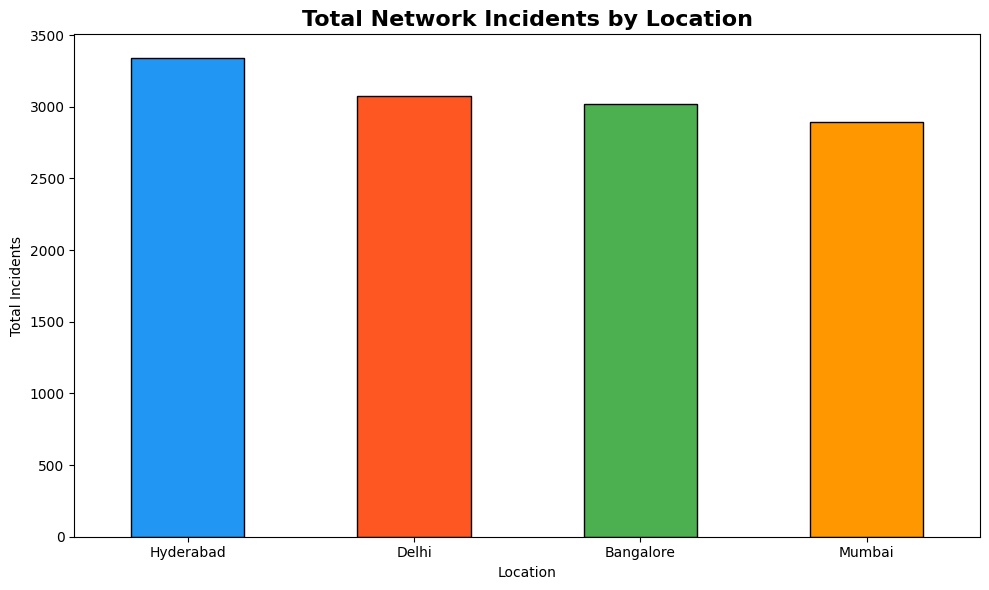

Chart 1 saved!


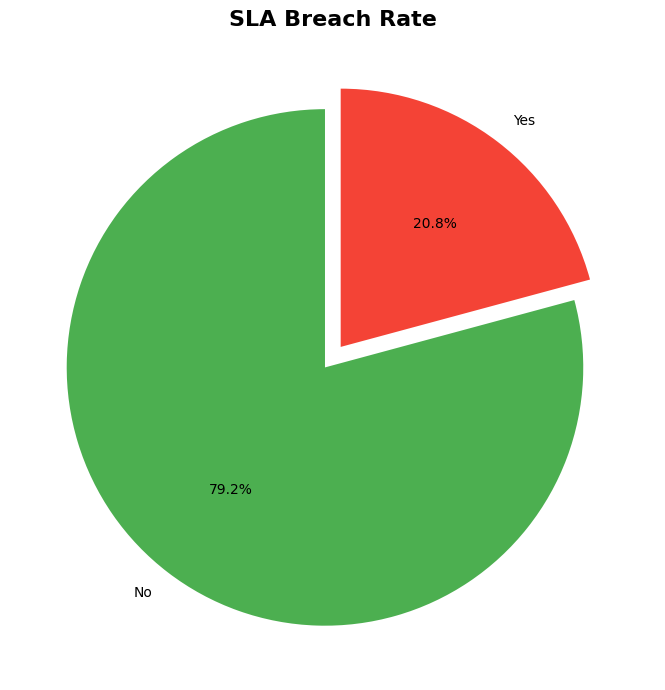

Chart 2 saved!


In [7]:
# VISUALIZATION 1 - Incidents by Location
plt.figure(figsize=(10,6))
df.groupby('Location')['Incidents'].sum().sort_values(ascending=False).plot(
    kind='bar', color=['#2196F3','#FF5722','#4CAF50','#FF9800'], edgecolor='black')
plt.title('Total Network Incidents by Location', fontsize=16, fontweight='bold')
plt.xlabel('Location')
plt.ylabel('Total Incidents')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('incidents_by_location.png', dpi=150)
plt.show()
print("Chart 1 saved!")

# VISUALIZATION 2 - SLA Breach
plt.figure(figsize=(7,7))
df['SLA_Breached'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', colors=['#4CAF50','#F44336'],
    startangle=90, explode=[0.05,0.05])
plt.title('SLA Breach Rate', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.savefig('sla_breach.png', dpi=150)
plt.show()
print("Chart 2 saved!")

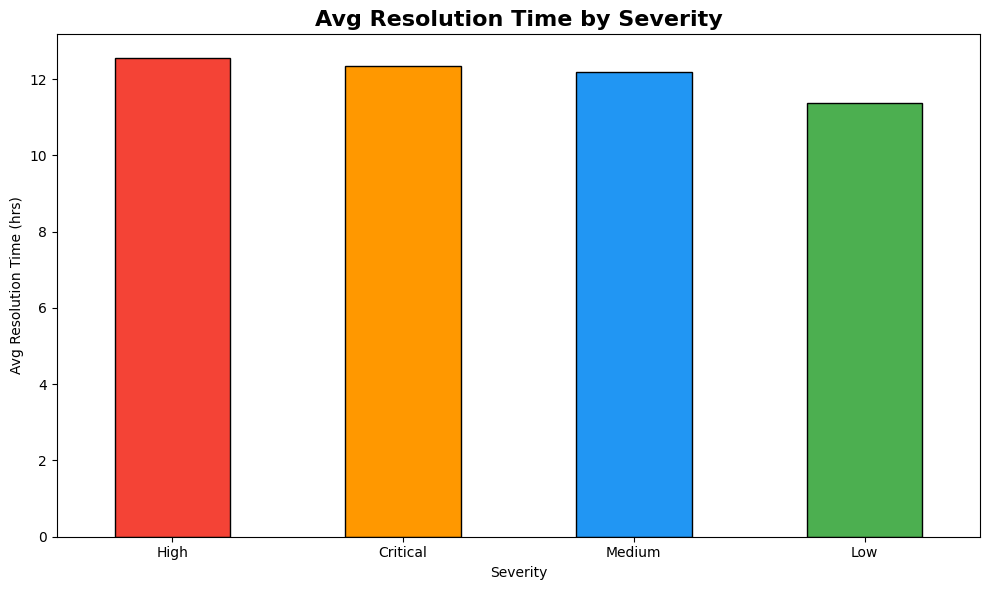

Chart 3 saved!


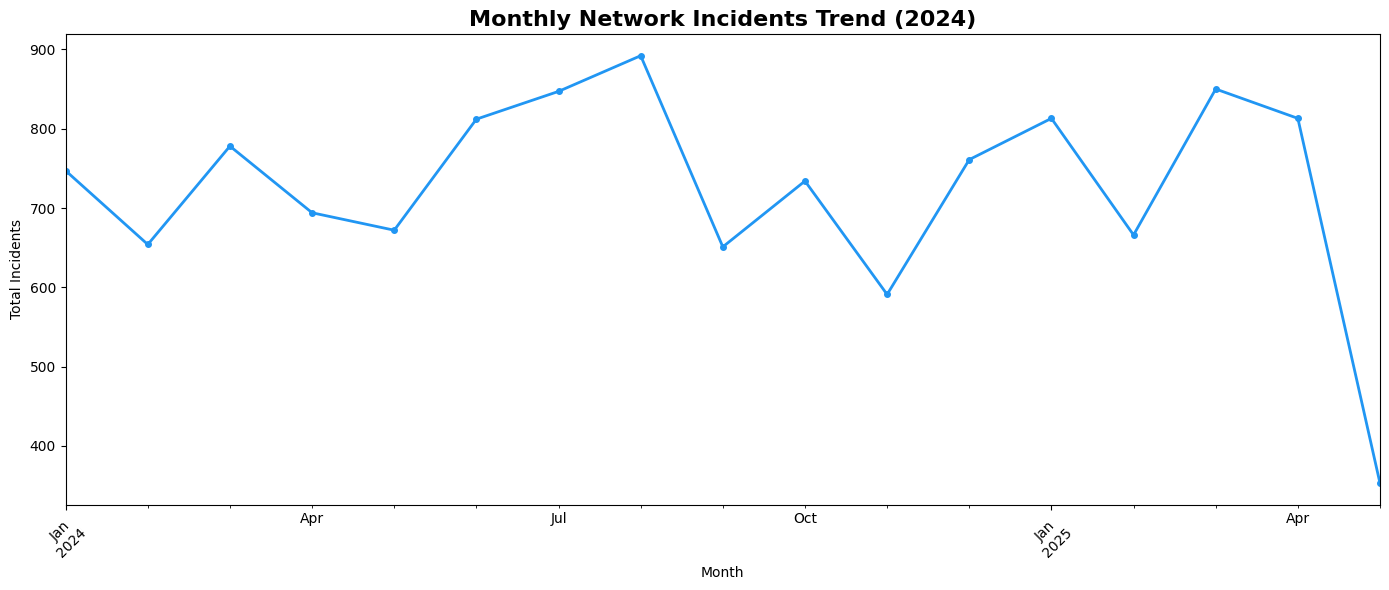

Chart 4 saved!


In [8]:
# VISUALIZATION 3 - Avg Resolution Time by Severity
plt.figure(figsize=(10,6))
df.groupby('Severity')['Resolution_Time_hrs'].mean().sort_values(ascending=False).plot(
    kind='bar', color=['#F44336','#FF9800','#2196F3','#4CAF50'], edgecolor='black')
plt.title('Avg Resolution Time by Severity', fontsize=16, fontweight='bold')
plt.xlabel('Severity')
plt.ylabel('Avg Resolution Time (hrs)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('resolution_by_severity.png', dpi=150)
plt.show()
print("Chart 3 saved!")

# VISUALIZATION 4 - Monthly Incidents Trend
df['Month'] = df['Date'].dt.to_period('M')
monthly = df.groupby('Month')['Incidents'].sum()
plt.figure(figsize=(14,6))
monthly.plot(kind='line', color='#2196F3', linewidth=2, marker='o', markersize=4)
plt.title('Monthly Network Incidents Trend (2024)', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Incidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()
print("Chart 4 saved!")

In [9]:
# CONCLUSIONS & KEY INSIGHTS
print("=" * 50)
print("   NETWORK OPERATIONS ANALYSIS - KEY INSIGHTS")
print("=" * 50)

print("\n📍 1. INCIDENTS BY LOCATION:")
location_incidents = df.groupby('Location')['Incidents'].sum().sort_values(ascending=False)
for loc, val in location_incidents.items():
    print(f"   {loc}: {val} incidents")

print("\n⚠️ 2. SLA BREACH RATE:")
breach_rate = df['SLA_Breached'].value_counts(normalize=True).mul(100).round(1)
print(f"   SLA Breached: {breach_rate['Yes']}% — Needs immediate attention!")

print("\n⏱️ 3. RESOLUTION TIME BY SEVERITY:")
res_time = df.groupby('Severity')['Resolution_Time_hrs'].mean().round(2)
for sev, val in res_time.items():
    print(f"   {sev}: {val} hrs avg")

print("\n🔧 4. MOST PROBLEMATIC DEVICE:")
top_device = df.groupby('Device_Type')['Incidents'].sum().idxmax()
print(f"   {top_device} has highest incident count")

print("\n📅 5. PEAK INCIDENT MONTH:")
peak_month = df.groupby('Month')['Incidents'].sum().idxmax()
print(f"   Peak incidents recorded in: {peak_month}")

print("\n✅ RECOMMENDATIONS:")
print("   - Prioritize Hyderabad infrastructure upgrades")
print("   - Reduce SLA breach rate from 20.8% to below 10%")
print("   - Focus on High severity resolution speed")
print("   - Increase monitoring during peak months")

   NETWORK OPERATIONS ANALYSIS - KEY INSIGHTS

📍 1. INCIDENTS BY LOCATION:
   Hyderabad: 3338 incidents
   Delhi: 3073 incidents
   Bangalore: 3021 incidents
   Mumbai: 2896 incidents

⚠️ 2. SLA BREACH RATE:
   SLA Breached: 20.8% — Needs immediate attention!

⏱️ 3. RESOLUTION TIME BY SEVERITY:
   Critical: 12.34 hrs avg
   High: 12.55 hrs avg
   Low: 11.38 hrs avg
   Medium: 12.19 hrs avg

🔧 4. MOST PROBLEMATIC DEVICE:
   Server has highest incident count

📅 5. PEAK INCIDENT MONTH:
   Peak incidents recorded in: 2024-08

✅ RECOMMENDATIONS:
   - Prioritize Hyderabad infrastructure upgrades
   - Reduce SLA breach rate from 20.8% to below 10%
   - Focus on High severity resolution speed
   - Increase monitoring during peak months
